## Figure: Agreement and Recource

In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
)
from monoculture.analysis.metrics import (
    pairwise_agreement_at_random,
    matrix_pairwise_evals,
    pairwise_agreement_at_random,
)

from monoculture.analysis.utils import load_model_outputs_same_prompt, get_metric
from monoculture.analysis.utils import load_task_data

from monoculture.analysis.metrics import observed_agreement_wrapper
from monoculture.analysis.plotting import (
    plot_agreement_lineplot,
    plot_recourse_barplot,
    plot_recourse_lineplot,
)

In [61]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

In [ ]:
# from seaborn import color_palette
# colors = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000', ]
# #color_palette("colorblind")
# plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

TASKS = ["ACSIncome"]  # ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/same-prompt/"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"

data_all = None

tasks ['ACSIncome']


## Load predictions ACSIncome

In [25]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["task"] == TASKS[0])
    & (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [26]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(df_same_prompt["task"].unique())
TASKS

(48, 14)


['ACSIncome']

In [27]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_all = {}  # [task][metric][model]
for task in df_same_prompt["task"].unique():
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_31021/1453958818.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_31021/1453958818.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_31021/1453958818.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

## Restrict analysis to models based on performance or true labels?

In [28]:
restrict_to_better_const = True
restrict_to_top_eps = True
restrict_to_topk = False
topk = 10
eps = 0.05
restrict_to_positive_label = True
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

predictions = predictions_all.copy()

if data_all:
    data = data_all.copy()
if any(
    [restrict_to_better_const, restrict_to_positive_label, restrict_to_negative_label]
):
    if not data_all:
        logging.warning("Load task data")
        data_all = load_task_data(TASKS, Path("./data"))
        data = data_all.copy()

    for task in TASKS:
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
            data[task] = (data[task][0].loc[filter_idx], data[task][1].loc[filter_idx])
        print(task, predictions[task].shape)

if restrict_to_topk or restrict_to_top_eps:
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)
        if restrict_to_topk:
            models = sorted(
                df_task_sorted_by_acc.iloc[:topk]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        if restrict_to_top_eps:
            top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
            models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
        print(task, predictions[task].shape)

evals_per_task = evals_per_task_all.copy()

evals_per_task = {
    task: {
        metric: {
            model: evals_per_task_all[task][metric][model]
            for model in predictions[task].columns
        }
        for metric in evals_per_task_all[task].keys()
    }
    for task in evals_per_task_all.keys()
}

ACSIncome (61233, 40)
ACSIncome (61233, 21)


In [29]:
len(evals_per_task["ACSIncome"]["accuracy"].keys())

21

## Plot

In [30]:
tp_rates = {
    task: 1.0
    - df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["fnr"]
    for task in TASKS
}

fp_rates = {
    task: 1.0
    - df_same_prompt[
        df_same_prompt.apply(
            lambda row: (row.task == task) & (row.model in predictions[task].columns),
            axis=1,
        )
    ]["fpr"]
    for task in TASKS
}

mean agreement: 0.894939661026001
agreement-recourse-0-shot-ACSIncome_tresh_fitted_better_const_pos_instances_eps0_05


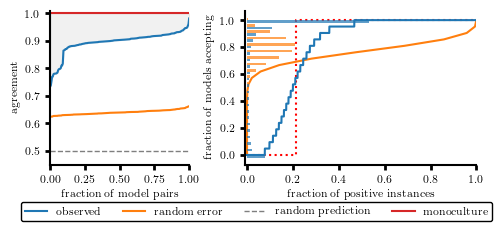

In [ ]:
tasks_to_plot = TASKS  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']


default_width = plt.rcParams['figure.figsize'][0]
# Set custom height
custom_height = 2 #plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    1, 
    2, 
    figsize=(default_width, custom_height),
    #constrained_layout=True,
    gridspec_kw={'width_ratios': [3/8, 5/8], 'wspace': 0.3}
) #figsize=(9 * len(tasks_to_plot), 3),

sort_by = None
for i, task in enumerate(tasks_to_plot):
    models_sorted = sorted(predictions[task].columns, key=get_size_and_it)
    M = len(models_sorted)

    # agreements without diagonal
    obs_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        partial(observed_agreement_wrapper, predictions=predictions[task]),
    ).fill_diagonal_(torch.nan)
    exp_agreement_matrix = matrix_pairwise_evals(
        models_sorted,
        fun=lambda m1, m2: pairwise_agreement_at_random(
            evals_per_task[task]["accuracy"][m1], evals_per_task[task]["accuracy"][m2]
        ),
    ).fill_diagonal_(torch.nan)

    axs[0] = plot_agreement_lineplot(
        axs[0],
        obs_agreement_matrix[~obs_agreement_matrix.isnan()],
        exp_agreement_matrix[~exp_agreement_matrix.isnan()],
        #  title="agreement rates",
        ylim=(0.45, 1.0),
    )
    print(
        f"mean agreement: {obs_agreement_matrix[~obs_agreement_matrix.isnan()].mean()}"
    )

    axs[0].set_ylabel("agreement")
    axs[0].set_xlabel("fraction of model pairs")

    axs[1], observed, at_random = plot_recourse_lineplot(
        axs[1],
        predictions=predictions[task],
        baseline_rates=tp_rates[task].to_list(),
        y_true=data[task][1],
        restrict_only_pos_instances=True,
        restrict_only_neg_instances=False,
        count_accepted=True,
        at_least=False,
        plot_pdf=True,
        xlabel="fraction of positive instances",
        ylabel="fraction of models accepting",
        num_ticks=6
    )

    # legend
    desired_order = ['observed', 'random error', 'random prediction', 'monoculture']
    handles, labels = axs[0].get_legend_handles_labels()
    unique = {}
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = h
    ordered_labels = [label for label in desired_order if label in unique]
    ordered_handles = [unique[label] for label in ordered_labels]

    fig.legend(
        ordered_handles,
        ordered_labels,
        loc="lower center",
        ncol=len(labels),
        bbox_to_anchor=(0.5, -0.2),
        bbox_transform=ax.transAxes,
        frameon=True,  # show box
        framealpha=1.0,  # opacity of box
        edgecolor="black",  # border color
        fancybox=True,
    )  # rounded corners)
    # fig.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))

    #fig.suptitle(task.replace('ACS', 'ACS ').replace('_', ' '))

file_name = "".join(
    [
        f"agreement-recourse-{num_shots}-shot",
        f"-{TASKS[0]}",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
        f"_eps{str(eps).replace('.', '_')}" if restrict_to_top_eps else "",
        f"_top{topk}" if restrict_to_topk else "",
    ]
)
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

In [67]:
observed[observed[:, 1] <= 0.5][-1], at_random[at_random[:, 1] <= 0.5][-1]

(array([0.19979423, 0.47619048]), array([0.0015815 , 0.47619048]))

In [33]:
observed[observed[:, 0] <= 0.2][-1], at_random[at_random[:, 0] <= 0.2][-1]

(array([0.1999902 , 0.52380952]), array([0.14014004, 0.66666667]))

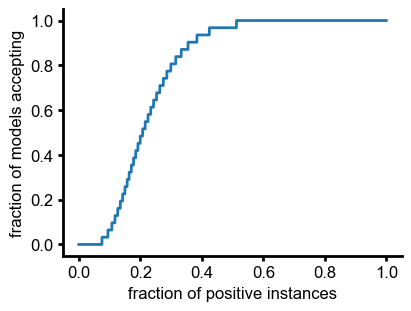

In [26]:
fig, axs = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)

N, M = predictions[task][data[task][1] == 1].shape
fraction_accepts = sorted(predictions[task][data[task][1] == 1].sum(axis=1).values / M)
fraction_individuals = np.arange(N) / N
axs.set_xlabel("fraction of positive instances")
axs.set_ylabel("fraction of models accepting")
axs.plot(fraction_individuals, fraction_accepts)
plt.show()

In [27]:
(predictions[task][data[task][1] == 1].sum(axis=1) == 0).sum() / N

0.07500857380824065

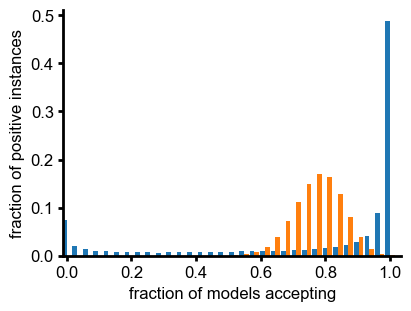

In [28]:
fig, axs = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
plot_recourse_barplot(
    axs,
    predictions=predictions[task],
    baseline_rates=tp_rates[task].to_list(),
    y_true=data[task][1],
    restrict_only_pos_instances=True,
    restrict_only_neg_instances=False,
    show_monoc=False,
    xlabel="fraction of models accepting",
    # plot_cumulative=True
)
plt.show()

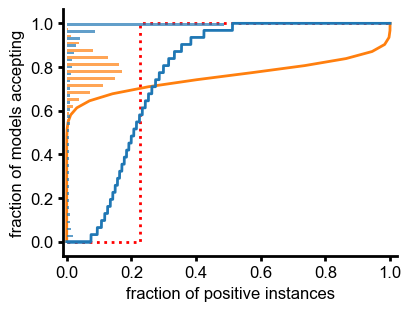

In [29]:
fig, axs = plt.subplots(1, 1, figsize=(4, 3), constrained_layout=True)
plot_recourse_lineplot(
    axs,
    predictions=predictions[task],
    baseline_rates=tp_rates[task].to_list(),
    y_true=data[task][1],
    restrict_only_pos_instances=True,
    restrict_only_neg_instances=False,
    at_least=False,
    plot_pdf=True,
)
plt.show()